In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings, itertools, pathlib
warnings.filterwarnings('ignore')
pathlib.Path('figs').mkdir(exist_ok=True)
_TAG = 'nb1'
_fig_counter = itertools.count(1)
def _save_show(*a, **k):
    import matplotlib.pyplot as _plt
    for _n in _plt.get_fignums():
        _plt.figure(_n).savefig('figs/%s_fig%02d.png' % (_TAG, next(_fig_counter)), dpi=140, bbox_inches='tight')
    _plt.close('all')
plt.show = _save_show


# Characterizing Orbital Perturbations via Physics-Informed Neural Networks  
## Notebook 1: Dataset Finalization, Synthetic Orbit Generation, and Sparse Observation Setup

This notebook is the starting point for the project:

**Characterizing Orbital Perturbations via Physics-Informed Neural Networks: An Inverse Problem Approach to Trajectory Reconstruction and Physical Parameter Discovery from Sparse Observation Data**

### Goals for this notebook
1. Finalize the role of each dataset in the project
2. Build a clean synthetic orbital dataset with known physics
3. Simulate sparse and noisy observations
4. Export data products that can later be used by a PINN
5. Establish a reproducible baseline before introducing real-world datasets such as TLEs or JPL Horizons

### Why start here?
A strong inverse-problem project needs at least one dataset where the true hidden parameter is known.  
Synthetic data gives complete control over:
- the perturbation model
- the hidden parameter value
- the observation cadence
- the noise level

That makes it the best first validation environment before moving to authentic but messier orbital data.


## 1. Dataset roles for the project

### Final recommended dataset strategy

**Primary development dataset**
- **Synthetic self-generated trajectories**
- Purpose: train and validate the first inverse-problem pipeline
- Why: the true perturbation strength is known, so the model can be tested honestly

**Secondary authenticity dataset**
- **Historical TLE data from Space-Track**
- Purpose: test whether the method still works with sparse real observations and orbital element parsing
- Why: this introduces authentic tracking data used in real space operations

**Benchmark / high-precision comparison dataset**
- **NASA JPL Horizons ephemerides**
- Purpose: provide high-quality reference trajectories for comparison and physical interpretation
- Why: this is useful when studying subtle deviations such as non-spherical gravity effects

**Optional advanced dataset**
- **SpaceTrack-TimeSeries**
- Purpose: later-stage evaluation with uncertainty-aware data products
- Why: this introduces covariance and more ML-friendly formatting

### Practical scope decision for the first coding phase
For the first notebook, the project should use:
1. synthetic orbit data only
2. sparse observation masks
3. controlled noise injection
4. exported CSV files for later PINN training

This keeps the first computational milestone achievable and scientifically defensible.


## 2. Environment setup

This notebook uses only standard scientific Python tools:
- `numpy`
- `pandas`
- `matplotlib`
- `scipy`

Later notebooks may add:
- `torch` or `tensorflow`
- `poliastro` or `skyfield`
- a PINN framework implementation


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=6, suppress=True)


## 3. Physical constants and helper functions

This first version works in kilometers and seconds.

The notebook includes:
- central two-body gravity
- optional Earth $J_2$ perturbation
- optional simple drag-like perturbation

The drag term here is intentionally simplified. Its role is not to be a perfect atmospheric model, but to create a hidden parameter that can later be inferred in an inverse problem.


In [ ]:

# Earth constants in km, s units
MU_EARTH = 398600.4418          # km^3 / s^2
R_EARTH = 6378.1363             # km
J2_EARTH = 1.08262668e-3        # dimensionless

# "Drag-like" parameter for a simple demonstrator model
# Units here are artificial but consistent with the implemented acceleration law.
DEFAULT_DRAG_COEFF = 3.245e-5

def norm(vec):
    return np.linalg.norm(vec)

def two_body_acceleration(r, mu=MU_EARTH):
    r_norm = norm(r)
    return -mu * r / (r_norm**3)

def j2_acceleration(r, mu=MU_EARTH, R=R_EARTH, J2=J2_EARTH):
    x, y, z = r
    r_norm = norm(r)
    z2 = z**2
    r2 = r_norm**2

    factor = 1.5 * J2 * mu * (R**2) / (r_norm**5)
    common = 5.0 * z2 / r2

    ax = factor * x * (common - 1.0)
    ay = factor * y * (common - 1.0)
    az = factor * z * (common - 3.0)
    return np.array([ax, ay, az])

def simple_drag_acceleration(r, v, drag_coeff=DEFAULT_DRAG_COEFF):
    '''
    A simple demonstration drag law:
    a_drag = -c_d * exp(-(r - R_earth)/H) * |v| * v

    This is not intended to be a mission-grade atmosphere model.
    It is a controlled perturbation for inverse-problem experiments.
    '''
    H = 60.0  # scale height in km for a toy model
    altitude = max(norm(r) - R_EARTH, 0.0)
    density_factor = np.exp(-altitude / H)
    speed = norm(v)
    return -drag_coeff * density_factor * speed * v

def orbital_dynamics(t, state, use_j2=True, use_drag=False, drag_coeff=DEFAULT_DRAG_COEFF):
    r = state[:3]
    v = state[3:]

    a = two_body_acceleration(r)

    if use_j2:
        a = a + j2_acceleration(r)
    if use_drag:
        a = a + simple_drag_acceleration(r, v, drag_coeff=drag_coeff)

    return np.concatenate([v, a])

def circular_velocity(radius_km, mu=MU_EARTH):
    return np.sqrt(mu / radius_km)




## 4. Define a baseline orbit

1.   List item
2.   List item



A low Earth orbit is chosen so that perturbations are more visible.

The state vector is:
- position: $(x, y, z)$ in km
- velocity: $(v_x, v_y, v_z)$ in km/s


In [ ]:

# Baseline orbit configuration
altitude_km = 500.0
radius0 = R_EARTH + altitude_km

# Slight inclination by adding a z component in velocity direction setup
r0 = np.array([radius0, 0.0, 0.0])
v_circ = circular_velocity(radius0)

inclination_deg = 35.0
inclination_rad = np.deg2rad(inclination_deg)

v0 = np.array([
    0.0,
    v_circ * np.cos(inclination_rad),
    v_circ * np.sin(inclination_rad)
])

state0 = np.concatenate([r0, v0])

print("Initial state [x, y, z, vx, vy, vz]:")
print(state0)
print(f"Initial speed = {norm(v0):.4f} km/s")


Initial state [x, y, z, vx, vy, vz]:
[6878.1363      0.          0.          0.          6.235884    4.366413]
Initial speed = 7.6126 km/s


## 5. Simulate the dense reference trajectory

This dense trajectory will act as the hidden "truth" dataset.

Three physics options can be compared:
1. two-body only
2. two-body + $J_2$
3. two-body + $J_2$ + drag-like perturbation

The inverse problem later will try to infer the perturbation strength from only partial observations.


In [ ]:

# Simulation time span
num_orbits = 8
orbital_period_est = 2 * np.pi * np.sqrt(radius0**3 / MU_EARTH)
t_final = num_orbits * orbital_period_est

n_eval = 2500
t_eval = np.linspace(0.0, t_final, n_eval)

sol_two_body = solve_ivp(
    lambda t, y: orbital_dynamics(t, y, use_j2=False, use_drag=False),
    (0.0, t_final),
    state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

sol_j2 = solve_ivp(
    lambda t, y: orbital_dynamics(t, y, use_j2=True, use_drag=False),
    (0.0, t_final),
    state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

TRUE_DRAG_COEFF = DEFAULT_DRAG_COEFF
sol_j2_drag = solve_ivp(
    lambda t, y: orbital_dynamics(t, y, use_j2=True, use_drag=True, drag_coeff=TRUE_DRAG_COEFF),
    (0.0, t_final),
    state0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

print("Integration complete.")
print(f"Simulated {num_orbits} orbits over {t_final/3600:.2f} hours.")


Integration complete.
Simulated 8 orbits over 12.62 hours.


## 6. Compare trajectories

The perturbations may look visually subtle in Cartesian coordinates, which is normal.  
Later, residual plots and parameter estimation will make the differences clearer.


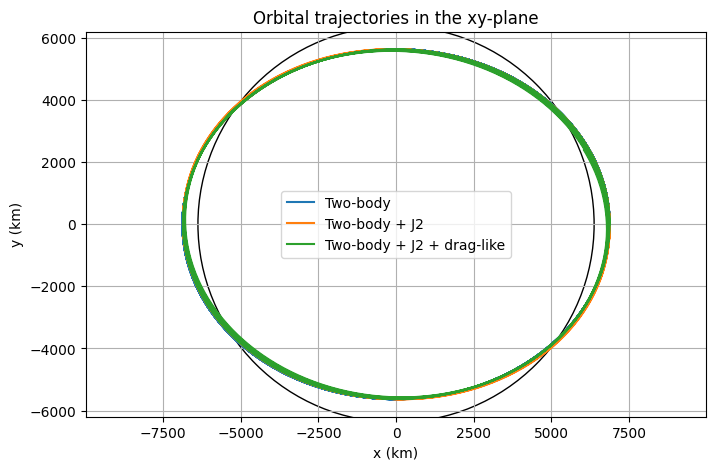

In [ ]:

fig, ax = plt.subplots()

ax.plot(sol_two_body.y[0], sol_two_body.y[1], label="Two-body")
ax.plot(sol_j2.y[0], sol_j2.y[1], label="Two-body + J2")
ax.plot(sol_j2_drag.y[0], sol_j2_drag.y[1], label="Two-body + J2 + drag-like")

earth = plt.Circle((0, 0), R_EARTH, fill=False)
ax.add_artist(earth)

ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Orbital trajectories in the xy-plane")
ax.axis("equal")
ax.legend()
plt.show()


In [ ]:
# [neutralized for headless run]
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 7. Quantify perturbation effects

Even when the orbits look similar by eye, the residuals can still accumulate.
These residuals are what make the inverse problem scientifically interesting.


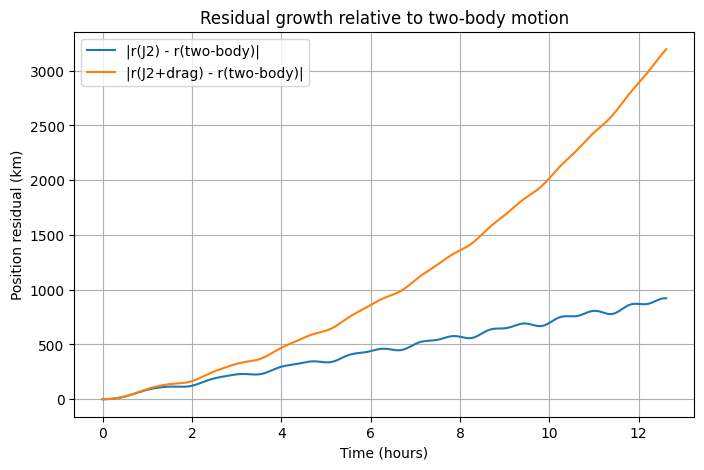

Final J2 residual: 921.849896 km
Final J2 + drag residual: 3195.948877 km


In [ ]:

r_two_body = sol_two_body.y[:3].T
r_j2 = sol_j2.y[:3].T
r_j2_drag = sol_j2_drag.y[:3].T

residual_j2 = np.linalg.norm(r_j2 - r_two_body, axis=1)
residual_j2_drag = np.linalg.norm(r_j2_drag - r_two_body, axis=1)

plt.plot(t_eval / 3600.0, residual_j2, label="|r(J2) - r(two-body)|")
plt.plot(t_eval / 3600.0, residual_j2_drag, label="|r(J2+drag) - r(two-body)|")
plt.xlabel("Time (hours)")
plt.ylabel("Position residual (km)")
plt.title("Residual growth relative to two-body motion")
plt.legend()
plt.show()

print(f"Final J2 residual: {residual_j2[-1]:.6f} km")
print(f"Final J2 + drag residual: {residual_j2_drag[-1]:.6f} km")


## 8. Simulate sparse observations

A major project goal is to reconstruct or infer physics from incomplete data.

This section converts the dense truth trajectory into a sparse observation set:
- only a subset of times are "observed"
- optional Gaussian measurement noise is added

This mimics realistic tracking conditions.


In [ ]:

rng = np.random.default_rng(42)

# Choose the dense trajectory with hidden perturbation as the truth dataset
truth_t = sol_j2_drag.t
truth_state = sol_j2_drag.y.T

# Sparse observation pattern
observe_every = 35
obs_idx = np.arange(0, len(truth_t), observe_every)

obs_t = truth_t[obs_idx]
obs_state = truth_state[obs_idx].copy()

# Add positional noise only for now
position_noise_std_km = 0.5
velocity_noise_std_kms = 0.002

obs_state_noisy = obs_state.copy()
obs_state_noisy[:, :3] += rng.normal(0.0, position_noise_std_km, size=obs_state_noisy[:, :3].shape)
obs_state_noisy[:, 3:] += rng.normal(0.0, velocity_noise_std_kms, size=obs_state_noisy[:, 3:].shape)

print(f"Number of dense points: {len(truth_t)}")
print(f"Number of sparse observations: {len(obs_t)}")


Number of dense points: 2500
Number of sparse observations: 72


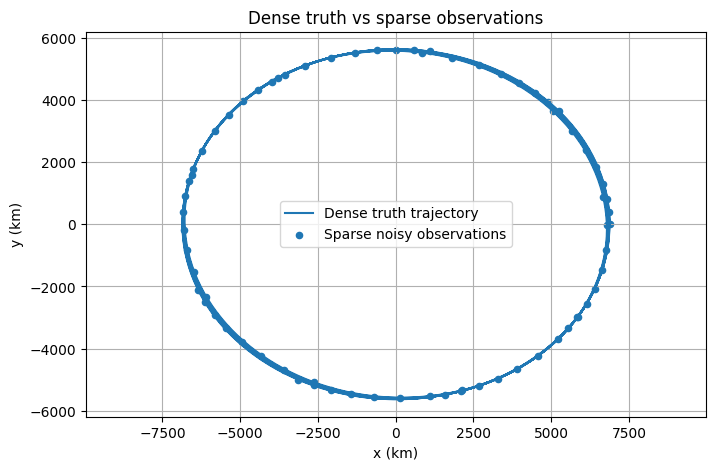

In [ ]:

plt.plot(truth_state[:, 0], truth_state[:, 1], label="Dense truth trajectory")
plt.scatter(obs_state_noisy[:, 0], obs_state_noisy[:, 1], s=20, label="Sparse noisy observations")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Dense truth vs sparse observations")
plt.axis("equal")
plt.legend()
plt.show()


## 9. Export project-ready datasets

These files can be used in later notebooks for:
- supervised trajectory fitting
- PINN training
- inverse parameter recovery
- benchmark comparisons


In [ ]:
# ------------------------------------------------------------
# Save the synthetic outputs to the same Google Drive folder
# where this notebook file lives whenever possible.
#
# This is especially useful in Colab, where saving to a bare
# filename would otherwise write to /content instead of Drive.
# ------------------------------------------------------------

from pathlib import Path
import os
import re

def detect_notebook_drive_folder():
    """Try to locate the current notebook's folder in Google Drive."""
    try:
        from google.colab import drive, output

        # Mount Drive only if it is not already mounted
        if not Path("/content/drive").exists():
            drive.mount("/content/drive")

        # The browser title usually looks like:
        # 'NotebookName.ipynb - Colaboratory'
        notebook_title = output.eval_js("document.title")
        notebook_name = re.sub(r"\s+-\s+Colaboratory.*$", "", notebook_title).strip()

        search_roots = [
            Path("/content/drive/MyDrive"),
            Path("/content/drive/Shareddrives"),
        ]

        candidates = []
        for root in search_roots:
            if root.exists():
                candidates.extend(root.rglob(notebook_name))

        if len(candidates) == 1:
            return candidates[0].parent
        elif len(candidates) > 1:
            # Choose the shortest path match and print all candidates for transparency
            candidates = sorted(candidates, key=lambda p: len(str(p)))
            print("Multiple notebook matches found in Drive. Using:")
            print(candidates[0].parent)
            print("\nOther matches:")
            for c in candidates[1:]:
                print(" -", c.parent)
            return candidates[0].parent

    except Exception as e:
        print("Could not auto-detect notebook folder in Drive:", e)

    # Fallback: save in the current working directory
    return Path.cwd()

SAVE_DIR = detect_notebook_drive_folder()
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving synthetic CSVs to:")
print(SAVE_DIR.resolve())

dense_df = pd.DataFrame({
    "t_sec": truth_t,
    "x_km": truth_state[:, 0],
    "y_km": truth_state[:, 1],
    "z_km": truth_state[:, 2],
    "vx_kms": truth_state[:, 3],
    "vy_kms": truth_state[:, 4],
    "vz_kms": truth_state[:, 5],
})

sparse_df = pd.DataFrame({
    "t_sec": obs_t,
    "x_km": obs_state_noisy[:, 0],
    "y_km": obs_state_noisy[:, 1],
    "z_km": obs_state_noisy[:, 2],
    "vx_kms": obs_state_noisy[:, 3],
    "vy_kms": obs_state_noisy[:, 4],
    "vz_kms": obs_state_noisy[:, 5],
})

metadata_df = pd.DataFrame({
    "parameter": [
        "true_drag_coeff",
        "use_j2",
        "position_noise_std_km",
        "velocity_noise_std_kms",
        "observe_every",
        "altitude_km",
        "inclination_deg",
        "n_dense_points",
        "n_sparse_points",
    ],
    "value": [
        TRUE_DRAG_COEFF,
        True,
        position_noise_std_km,
        velocity_noise_std_kms,
        observe_every,
        altitude_km,
        inclination_deg,
        len(truth_t),
        len(obs_t),
    ]
})

dense_path = SAVE_DIR / "synthetic_dense_truth.csv"
sparse_path = SAVE_DIR / "synthetic_sparse_observations.csv"
metadata_path = SAVE_DIR / "synthetic_metadata.csv"

dense_df.to_csv(dense_path, index=False)
sparse_df.to_csv(sparse_path, index=False)
metadata_df.to_csv(metadata_path, index=False)

print(f"Saved: {dense_path}")
print(f"Saved: {sparse_path}")
print(f"Saved: {metadata_path}")

# Optional local copies too, which can help if Notebook 2 is run
# in the same runtime before Drive is remounted.
dense_df.to_csv("synthetic_dense_truth.csv", index=False)
sparse_df.to_csv("synthetic_sparse_observations.csv", index=False)
metadata_df.to_csv("synthetic_metadata.csv", index=False)

print("\nAlso wrote local runtime copies in:")
print(Path.cwd().resolve())

dense_df.head()


Saved: synthetic_dense_truth.csv
Saved: synthetic_sparse_observations.csv
Saved: synthetic_metadata.csv


,t_sec,x_km,y_km,z_km,vx_kms,vy_kms,vz_kms
0,0.000000,6878.136300,0.000000,0.000000,0.000000,6.235884,4.366413
1,18.173596,6876.742609,113.320721,79.348005,-0.153370,6.234614,4.365520
2,36.347193,6872.562103,226.595395,158.663659,-0.306678,6.230817,4.362853
3,54.520789,6865.596480,339.778120,237.914713,-0.459861,6.224495,4.358411
4,72.694385,6855.848568,452.823026,317.068940,-0.612858,6.215650,4.352198


## 10. First inverse-problem baseline idea

Before training a full PINN, the project should establish a simple baseline.

### Controlled baseline task
Given sparse observations, estimate the hidden drag-like coefficient by:
1. guessing a coefficient
2. numerically integrating the orbit
3. comparing the simulated positions to the observed positions
4. choosing the coefficient that minimizes the trajectory mismatch

For this **first baseline**, the initial state is assumed known.  
That keeps the task focused on **parameter recovery only**.

This is not yet a PINN, but it creates an important comparison target.

If the PINN later solves the same task more efficiently, more robustly, or from noisier or less complete data, the project gains a strong scientific narrative.


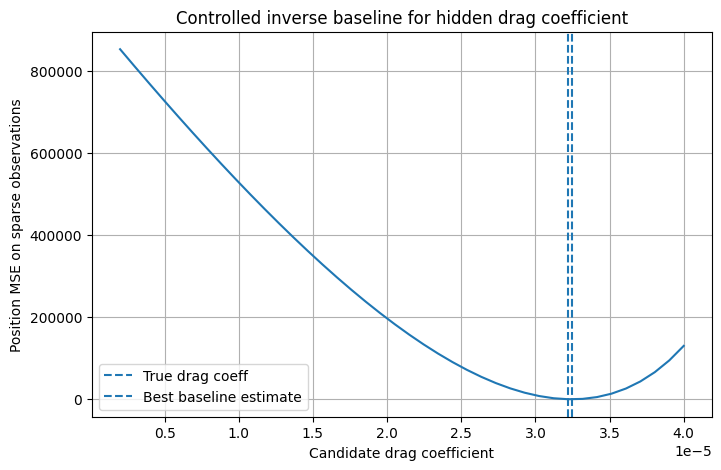

True drag coefficient:     0.00003245
Best baseline coefficient: 0.00003221
Absolute error:            0.00000024


In [ ]:

def simulate_positions_for_drag(drag_coeff, t_eval_subset, initial_state):
    sol = solve_ivp(
        lambda t, y: orbital_dynamics(t, y, use_j2=True, use_drag=True, drag_coeff=drag_coeff),
        (float(t_eval_subset[0]), float(t_eval_subset[-1])),
        initial_state,
        t_eval=t_eval_subset,
        rtol=1e-8,
        atol=1e-8
    )
    return sol.y[:3].T

# Controlled inverse baseline:
# assume the initial state is known so the only unknown is the perturbation strength
initial_state_known = truth_state[0].copy()

candidate_drag_values = np.linspace(0.2e-5, 4.0e-5, 40)
losses = []

for c in candidate_drag_values:
    pred_pos = simulate_positions_for_drag(c, obs_t, initial_state_known)
    observed_pos = obs_state_noisy[:, :3]
    mse = np.mean(np.sum((pred_pos - observed_pos)**2, axis=1))
    losses.append(mse)

losses = np.array(losses)
best_idx = np.argmin(losses)
best_drag = candidate_drag_values[best_idx]

plt.plot(candidate_drag_values, losses)
plt.axvline(TRUE_DRAG_COEFF, linestyle="--", label="True drag coeff")
plt.axvline(best_drag, linestyle="--", label="Best baseline estimate")
plt.xlabel("Candidate drag coefficient")
plt.ylabel("Position MSE on sparse observations")
plt.title("Controlled inverse baseline for hidden drag coefficient")
plt.legend()
plt.show()

print(f"True drag coefficient:     {TRUE_DRAG_COEFF:.8f}")
print(f"Best baseline coefficient: {best_drag:.8f}")
print(f"Absolute error:            {abs(best_drag - TRUE_DRAG_COEFF):.8f}")


## 11. What has been accomplished?

This notebook already establishes the first scientifically meaningful milestone:

- a controlled orbital dynamics simulator
- a hidden perturbation parameter
- sparse and noisy observations
- exportable data tables
- a baseline inverse estimation procedure

That means the project now has a complete data-generation and evaluation loop.

## 12. What should come next?

### Notebook 2
Build the first PINN or physics-constrained neural network that:
- takes time as input
- predicts state variables
- minimizes both data loss and physics residual loss
- treats the perturbation strength as a learnable parameter

### Notebook 3
Introduce real-world data:
- parse TLE snapshots
- convert to a usable time-series representation
- compare behavior against the synthetic pipeline

### Notebook 4
Benchmark against high-precision data from JPL Horizons.


## 13. Checklist to complete:

- Change altitude and inclination and observe what happens to perturbation visibility
- Increase or decrease the observation sparsity
- Increase or decrease the noise level
- Replace the drag-like perturbation with a pure $J_2$ discovery task
- Save several synthetic datasets with different hidden parameter values
- Prepare one clean figure for the proposal or report

## 14. Reflection Question:
Why is synthetic data necessary before applying a PINN to real TLE or ephemeris data?


In [ ]:

import json
_m = dict(
    true_drag_coeff=float(TRUE_DRAG_COEFF),
    baseline_best_drag=float(best_drag),
    baseline_abs_error=float(abs(best_drag - TRUE_DRAG_COEFF)),
    baseline_rel_error_pct=float(100*abs(best_drag - TRUE_DRAG_COEFF)/TRUE_DRAG_COEFF),
    candidate_grid_step=float(candidate_drag_values[1]-candidate_drag_values[0]),
    J2_used=float(J2_EARTH),
    altitude_km=float(altitude_km),
    inclination_deg=float(inclination_deg),
    num_orbits=int(num_orbits),
    orbital_period_min=float(orbital_period_est/60.0),
    t_final_hours=float(t_final/3600.0),
    n_dense=int(len(truth_t)),
    n_sparse=int(len(obs_t)),
    observe_every=int(observe_every),
    position_noise_std_km=float(position_noise_std_km),
    velocity_noise_std_kms=float(velocity_noise_std_kms),
    final_residual_J2_km=float(residual_j2[-1]),
    final_residual_J2_drag_km=float(residual_j2_drag[-1]),
    max_residual_J2_drag_km=float(residual_j2_drag.max()),
    initial_speed_kms=float(norm(v0)),
)
json.dump(_m, open('/tmp/pinn_run/results/nb1_metrics.json','w'), indent=2)
print('NB1_METRICS', json.dumps(_m, indent=2))


In [ ]:
print('FIG_FILES', sorted(__import__('os').listdir('figs')))